# Notebook 02: Phase 1 — Market Clustering

## Purpose
Use K-means clustering to identify which prediction markets are structurally
attractive targets for insider trading, without being told which markets were
actually targeted.

## Hypothesis
Markets with high uncertainty at open, high trading intensity, short time to
resolution, large average trade size, high late capital concentration, and high
trade concentration among a small number of wallets are more attractive to
informed traders. K-means clustering should group these markets together without
prior knowledge of which ones were known insider targets.

## Validation
Known insider-targeted markets (Maduro capture, US/Israel strikes on Iran,
Google Year in Search / d4vd, State of the Union attendance, George Santos)
are checked against cluster assignments after the blind run. If the hypothesis
holds, they should concentrate in the cluster with the highest structural
attractiveness profile.

## Features
- `uncertainty` — deviation from fair even-split price at open
- `trading_intensity` — total volume divided by duration in hours
- `time_to_resolution_hrs` — market duration in hours
- `avg_trade_size` — mean dollars per trade
- `late_capital_ratio` — fraction of volume in final 48 hours
- `top3_wallet_concentration` — fraction of volume from top 3 wallets

## Inputs
- `data/raw/markets_polymarket.parquet` — 7,623 markets with all features

## Outputs
- `data/processed/features_stage1.parquet` — engineered features per market
- `data/processed/cluster_assignments.parquet` — cluster label per market
- `outputs/clusters_pca.png` — PCA visualization

In [1]:
# Cell 2 — Imports and setup
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../outputs").mkdir(parents=True, exist_ok=True)

print("Ready.")

Ready.


In [52]:
# Cell 3 — Load data and engineer features

df = pd.read_parquet("../data/raw/markets_polymarket.parquet")

# Drop markets missing Dune trade features including velocity ratio
df = df.dropna(subset=["total_volume", "duration_hrs", "late_capital_ratio", 
                        "top3_wallet_concentration", "avg_trade_size", "velocity_ratio"]).copy()

print(f"Markets after dropping missing Dune data: {len(df)}")

# Feature: trading intensity — average dollars traded per hour
df["trading_intensity"] = df["total_volume"] / df["duration_hrs"].replace(0, np.nan)

# Drop markets missing opening_price or trading_intensity
df = df.dropna(subset=["opening_price", "trading_intensity"]).copy()

print(f"Markets after feature engineering: {len(df)}")

# Drop crypto, esports, and tweet markets categories
drop_categories = ["Bitcoin", "Crypto", "Crypto Prices", "Ethereum", "Solana", "XRP",
                   "Ripple", "Dogecoin", "BNB", "Memecoins", "cryptocurrency",
                   "Esports", "NFL Playoffs"]

df = df[~df["category"].isin(drop_categories)].copy()

# Filter out tweet count markets from Elon Musk category
tweet_mask = df["question"].str.contains("tweet", case=False, na=False)
df = df[~tweet_mask].copy()

print(f"Markets after dropping crypto, esports: {len(df)}")

# Final feature set
features = ["opening_price", "trading_intensity", "avg_trade_size", 
            "late_capital_ratio", "top3_wallet_concentration", "velocity_ratio"]

print(f"\nFeature summary:")
print(df[features].describe().round(3))

# Save
df.to_parquet("../data/processed/features_stage1.parquet", index=False)
print(f"\nSaved to features_stage1.parquet")

Markets after dropping missing Dune data: 6590
Markets after feature engineering: 5822
Markets after dropping crypto, esports: 2310

Feature summary:
       opening_price  trading_intensity  avg_trade_size  late_capital_ratio  \
count       2310.000           2310.000        2310.000            2310.000   
mean           0.256           5716.370         105.384               0.403   
std            0.244          29832.302         168.728               0.373   
min            0.000              0.054           0.019               0.000   
25%            0.037             84.990          29.588               0.033   
50%            0.165            360.307          53.131               0.285   
75%            0.480           1555.084         113.205               0.787   
max            1.000         611068.800        2257.004               1.000   

       top3_wallet_concentration  velocity_ratio  
count                   2310.000        2310.000  
mean                       0.723    

In [53]:
# Cell 4 — Normalize features

df = pd.read_parquet("../data/processed/features_stage1.parquet")

# Log-transform trading_intensity and avg_trade_size to handle extreme outliers
df["log_trading_intensity"] = np.log1p(df["trading_intensity"])
df["log_avg_trade_size"] = np.log1p(df["avg_trade_size"])

features = ["opening_price", "log_trading_intensity", "log_avg_trade_size",
            "late_capital_ratio", "top3_wallet_concentration", "velocity_ratio"]

# Normalize with StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

print(f"Feature matrix shape: {X.shape}")
print(f"\nFeatures after scaling (mean should be ~0, std ~1):")
print(pd.DataFrame(X, columns=features).describe().round(3))

Feature matrix shape: (2310, 6)

Features after scaling (mean should be ~0, std ~1):
       opening_price  log_trading_intensity  log_avg_trade_size  \
count       2310.000               2310.000            2310.000   
mean          -0.000                  0.000               0.000   
std            1.000                  1.000               1.000   
min           -1.045                 -2.537              -3.885   
25%           -0.896                 -0.643              -0.636   
50%           -0.372                 -0.025              -0.091   
75%            0.917                  0.603               0.622   
max            3.043                  3.173               3.471   

       late_capital_ratio  top3_wallet_concentration  velocity_ratio  
count            2310.000                   2310.000        2310.000  
mean               -0.000                     -0.000          -0.000  
std                 1.000                      1.000           1.000  
min                -1.080  

In [54]:
# Cell 5 — K-means clustering

# Run K-means with k=3, blind run
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

print(f"Cluster sizes:")
print(df["cluster"].value_counts().sort_index())

print(f"\nCluster profiles (mean feature values):")
print(df.groupby("cluster")[["opening_price", "trading_intensity", "avg_trade_size",
                              "late_capital_ratio", "top3_wallet_concentration"]].mean().round(3))

Cluster sizes:
cluster
0    1072
1    1238
Name: count, dtype: int64

Cluster profiles (mean feature values):
         opening_price  trading_intensity  avg_trade_size  late_capital_ratio  \
cluster                                                                         
0                0.376          11999.873         177.384                0.51   
1                0.152            275.405          43.039                0.31   

         top3_wallet_concentration  
cluster                             
0                            0.593  
1                            0.835  


In [55]:
# Cell 6
# Checking location of known insider markets

for name, cid in {"d4vd": "0xeaf59fcbf65e45abac0383dad483239d849e6d48d9eb2a6b3bf5cc1c7e9cf2ad"}.items():
    row = df[df["market_id"] == cid]
    if len(row) > 0:
        print(f"{name}: cluster {row['cluster'].values[0]}")

known_questions = [
    "Maduro in U.S. custody by January 31",
    "Will George Santos attend the 2026 State of the Union",
]
for q in known_questions:
    matches = df[df["question"].str.contains(q, case=False, na=False)]
    for _, row in matches.iterrows():
        print(f"{row['question'][:60]}: cluster {row['cluster']}, velocity_ratio: {row['velocity_ratio']:.3f}")

for kw in ["maduro", "iran", "state of the union", "santos"]:
    matches = df[df["question"].str.contains(kw, case=False, na=False)]
    print(f"\n{kw} ({len(matches)} markets):")
    print(matches["cluster"].value_counts())

d4vd: cluster 0
Maduro in U.S. custody by January 31?: cluster 0, velocity_ratio: 1.000
Will George Santos attend the 2026 State of the Union addres: cluster 0, velocity_ratio: 1.061

maduro (12 markets):
cluster
0    9
1    3
Name: count, dtype: int64

iran (191 markets):
cluster
0    156
1     35
Name: count, dtype: int64

state of the union (49 markets):
cluster
1    33
0    16
Name: count, dtype: int64

santos (2 markets):
cluster
1    1
0    1
Name: count, dtype: int64


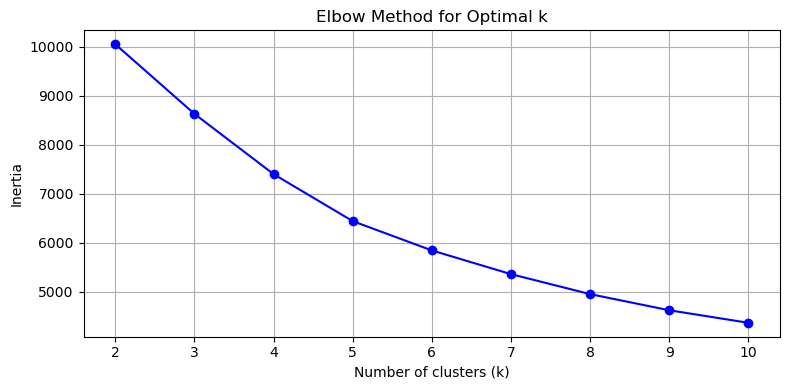

Saved to ../outputs/elbow_plot.png


In [ ]:
# Cell 7

# Elbow test — find optimal k
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/elbow_plot.png', dpi=150)
plt.show()
print("Saved to ../outputs/elbow_plot.png")

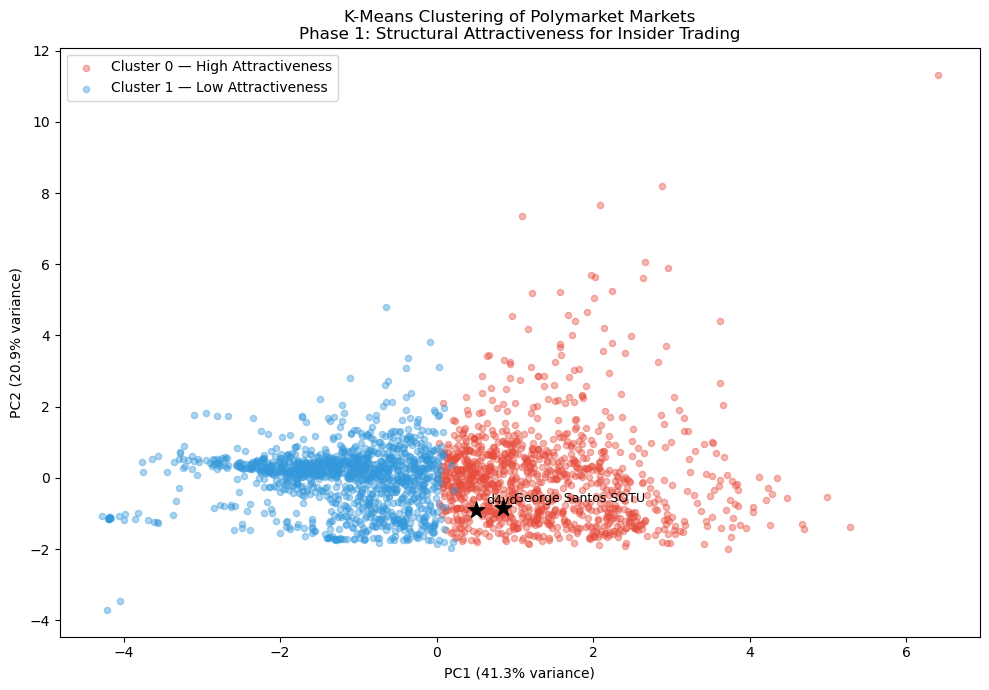

Explained variance: 62.2%


In [ ]:
# Cell 8 — PCA Visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))

colors = ["#e74c3c", "#3498db"]
labels = ["Cluster 0 — High Attractiveness", "Cluster 1 — Low Attractiveness"]

for cluster_id, color, label in zip([0, 1], colors, labels):
    mask = df["cluster"] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, label=label, alpha=0.4, s=20
    )

# Highlight known insider markets
known = {
    "d4vd": "0xeaf59fcbf65e45abac0383dad483239d849e6d48d9eb2a6b3bf5cc1c7e9cf2ad",
    "Maduro": "0x9d514ad9a0d14732439ee8a9a74ba0740802417cb7374fa205868bc1d595f797",
    "George Santos SOTU": df[df["question"].str.contains("George Santos attend", case=False, na=False)].iloc[0]["market_id"]
}

for name, cid in known.items():
    idx = df[df["market_id"] == cid].index
    if len(idx) > 0:
        i = df.index.get_loc(idx[0])
        plt.scatter(X_pca[i, 0], X_pca[i, 1], 
                   c="black", s=150, zorder=5, marker="*")
        plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), 
                    textcoords="offset points", xytext=(8, 4), fontsize=9)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("K-Means Clustering of Polymarket Markets\nPhase 1: Structural Attractiveness for Insider Trading")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/clusters_pca.png", dpi=150)
plt.show()
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

In [77]:
# Cell 9: Isolation Forest on suspicious markets

from sklearn.ensemble import IsolationForest

# Filter to Cluster 0 markets only
cluster0 = df[df["cluster"] == 0].copy()

# Feature set for Isolation Forest
if_features = ["opening_price", "log_trading_intensity", "log_avg_trade_size",
               "late_capital_ratio", "top3_wallet_concentration", "velocity_ratio"]

X_if = scaler.transform(cluster0[if_features])

# Run Isolation Forest
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
cluster0["anomaly_score"] = iso.fit_predict(X_if)
cluster0["anomaly_raw"] = iso.decision_function(X_if)

# -1 = anomaly, 1 = normal
print(f"Anomalies detected: {(cluster0['anomaly_score'] == -1).sum()}")
print(f"Normal markets: {(cluster0['anomaly_score'] == 1).sum()}")

# Show most anomalous markets
print("\nAll anomalous markets:")
print(cluster0.nsmallest(54, "anomaly_raw")[["question", "anomaly_raw", "velocity_ratio", 
    "late_capital_ratio", "opening_price", "avg_trade_size", 
    "top3_wallet_concentration"]].to_string())

Anomalies detected: 54
Normal markets: 1018

All anomalous markets:
                                                                                           question  anomaly_raw  velocity_ratio  late_capital_ratio  opening_price  avg_trade_size  top3_wallet_concentration
1016                                Tesla launches unsupervised full self driving (FSD) by June 30?    -0.163953        5.303935            0.373195         0.6500      832.739158                   0.253831
1721                                                        Will Donald Trump visit France in 2025?    -0.100433        3.490469            0.113572         0.7050       17.868768                   0.587564
571                                             Will Melania say "Career" during AI talk on Friday?    -0.078676        1.014192            0.984121         0.3550     2257.004270                   0.187715
1718                                                         Will Donald Trump visit Japan in 2025?    -

In [78]:
# Save outputs
df.to_parquet("../data/processed/cluster_assignments.parquet", index=False)

cluster0_anomalies = cluster0[cluster0["anomaly_score"] == -1].copy()
cluster0_anomalies.to_parquet("../data/processed/anomalies_stage1.parquet", index=False)

print(f"Saved {len(df)} markets with cluster assignments")
print(f"Saved {len(cluster0_anomalies)} anomalous markets")

Saved 2310 markets with cluster assignments
Saved 54 anomalous markets
